# CBDATSI Project — Phases 1 and 2: Collision-Type Focus

**Members:**
- Borromeo, Ed Bennett
- Dompor, Rovick
- Fuentes, Matthew

Reusable constants, cleaning functions, statistics, clustering, inference, and plotting live in `src/models/` and are imported below. `RTA_EDSA_2007-2016.csv` is located automatically from the `dataset/` folder.

# Section 1: Dataset Description

The `RTA_EDSA_2007-2016` dataset contains officially recorded road traffic accidents along Epifanio de los Santos Avenue (EDSA), Metro Manila, from 2007 through 2016. Each row represents an accident report, while each column describes an aspect of the incident. The CSV contains 22,072 observations and 26 variables.

### 1.1 Collection Method

Luz and Blanco published the dataset through Mendeley Data. They obtained the records from the Metro Manila Development Authority through the Data for Road Incident Visualization, Evaluation, and Reporting (DRIVER) System. The stated primary sources were MMDA Metrobase, the MMDA Road Safety Unit, and the Philippine National Police Traffic Management Group. 

The original `.xls` file was converted to `.csv` for this project.

### 1.2 Implications of the Collection Method

- **Restricted scope:** Results describe EDSA during 2007–2016 and should not be generalized automatically to current conditions or other roads.
- **Reporting bias:** The data covers officially recorded accidents. Unreported or privately resolved incidents are absent.
- **Measurement limitations:** Collision type, severity, time, and coordinates depend on the source record and reporting process.
- **Missing context:** Traffic volume, vehicle speed, detailed driver behavior, and consistent weather information are unavailable.

Consequently, the study identifies historical patterns in recorded accidents rather than causes or present-day collision probabilities.

### 1.3 Description of All Variables

| Variable | Meaning |
|---|---|
| `LOCATION_TEXT` | Text description of the accident location |
| `ROAD` | Road on which the accident occurred |
| `WEATHER` | Recorded weather condition |
| `LIGHT` | Recorded lighting condition |
| `DESC` | Additional incident description |
| `REPORTING_AGENCY` | Agency that reported the incident |
| `MAIN_CAUSE` | Cause assessed by the reporting agent |
| `INCIDENTDETAILS_ID` | Accident-record identifier |
| `DATE_UTC`, `TIME_UTC` | Accident date and time in UTC |
| `ADDRESS` | Descriptive street address |
| `killed_driver`, `killed_passenger`, `killed_pedestrian` | Death counts by road-user category |
| `injured_driver`, `injured_passenger`, `injured_pedestrian` | Injury counts by road-user category |
| `killed_uncategorized`, `injured_uncategorized` | Death and injury counts without a road-user category |
| `killed_total`, `injured_total` | Total recorded deaths and injuries |
| `DATETIME_PST` | Local Philippine accident date and time |
| `SEVERITY` | Property, Injury, or Fatal classification |
| `X` | Longitude of the recorded location |
| `Y` | Latitude of the recorded location |
| `COLLISION_TYPE` | Reported collision configuration |

This study uses `DATETIME_PST`, `SEVERITY`, `X`, `Y`, and `COLLISION_TYPE`. Raw coordinates replace `ADDRESS` because Phase 2 will examine spatial patterns without predefined geographic sectors.

# Section 2: Data Cleaning

The processing, EDA, clustering, and plotting functions used below are imported from the project's `src/models/` package, which is covered by the automated pytest suite.

The next cell imports the libraries and the project modules. Every reusable function used in this notebook is defined in `src/models/` and tested in `src/tests/`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))

from models.data_processing import (
    DataPipeline,
    COLLISION_TYPES,
    STUDY_VARIABLES,
    TIME_BIN_LABELS,
    UNKNOWN_COLLISION_TYPE,
    VALID_SEVERITIES,
    X_MIN,
    X_MAX,
    Y_MIN,
    Y_MAX,
)
from models.eda import (
    collision_count_statistics,
    collision_frequency_table,
    densest_coordinate_cell,
    hour_statistics,
    hourly_collision_counts,
    hourly_pattern_correlations,
    modal_hour_by_collision,
    overall_coordinate_correlation,
    overall_coordinate_statistics,
    severity_count_correlations,
    severity_distribution,
    time_distribution,
)
from models.eda_plots import (
    plot_collision_frequency,
    plot_coordinate_density,
    plot_hourly_collision_heatmap,
    plot_severity_distribution,
)

dp = DataPipeline()

plt.style.use("seaborn-v0_8-whitegrid")

The raw CSV is loaded before any variables are removed. Its dimensions and column names confirm the reported structure and allow later checks to distinguish full-record duplicates from records that merely share the selected study values.

In [2]:
dataset_path = dp.find_dataset_path()
raw_df = dp.load_dataset(dataset_path)
print("Dataset path:", dataset_path)
print(f"Raw shape: {raw_df.shape}")
print(raw_df.columns.tolist())

Dataset path: C:\Users\user\Desktop\cbsweg2\CBSWEG2_local\dataset\RTA_EDSA_2007-2016.csv
Raw shape: (22072, 26)
['LOCATION_TEXT', 'ROAD', 'WEATHER', 'LIGHT', 'DESC', 'REPORTING_AGENCY', 'MAIN_CAUSE', 'INCIDENTDETAILS_ID', 'DATE_UTC', 'TIME_UTC', 'ADDRESS', 'killed_driver', 'killed_passenger', 'killed_pedestrian', 'injured_driver', 'injured_passenger', 'injured_pedestrian', 'killed_uncategorized', 'injured_uncategorized', 'killed_total', 'injured_total', 'DATETIME_PST', 'SEVERITY', 'Y', 'X', 'COLLISION_TYPE']


Only the five variables required by the revised study are selected. The audit checks data types, missing values, categorical representations, and duplicate rows. It is performed before filtering so that removal decisions remain transparent.

In [3]:
study_df = dp.select_study_variables(raw_df)
audit = dp.audit_study_data(study_df)

print(f"Selected shape: ({audit['rows']}, {audit['columns']})")
print("\nData types:")
print(audit["dtypes"])
print("\nMissing values:")
print(audit["missing"])
print("\nSeverity values:", audit["severity_values"])
print("Collision-type values:", audit["collision_type_values"])
print("Selected-field duplicate rows:", audit["exact_duplicate_rows"])

Selected shape: (22072, 5)

Data types:
DATETIME_PST       object
SEVERITY           object
X                 float64
Y                 float64
COLLISION_TYPE     object
dtype: object

Missing values:
DATETIME_PST      0
SEVERITY          0
X                 0
Y                 0
COLLISION_TYPE    0
dtype: int64

Severity values: ['Fatal', 'Injury', 'Property']
Collision-type values: ['Angle Impact', 'Head-On', 'Hit Object', 'Multiple', 'No Collision Stated', 'Rear-End', 'Self-Accident', 'Side Swipe']
Selected-field duplicate rows: 49


The five variables contain no missing values. Their category labels are consistently formatted. 

`DATETIME_PST` requires conversion from text to datetime; the other types are appropriate. There are 49 repeated combinations of the five selected values, but the complete source has no fully duplicated rows. Different source records can share a time, coordinate, severity, and collision type, so these observations are retained rather than assumed to be duplicate accidents.

In [4]:
apparent_duplicates = dp.find_apparent_duplicates(study_df)
print("Rows participating in repeated selected-value combinations:", len(apparent_duplicates))
print("Duplicate complete source rows:", int(raw_df.duplicated().sum()))
print("Duplicate source identifiers:", int(raw_df["INCIDENTDETAILS_ID"].duplicated().sum()))

Rows participating in repeated selected-value combinations: 97
Duplicate complete source rows: 0
Duplicate source identifiers: 1


`No Collision Stated` is a default-like value rather than an observed collision configuration. Because collision type will characterize the Phase 2 clusters, these records cannot answer the research question and are removed. The excluded share is reported because such a large reduction may bias the retained sample toward accidents with more complete reports.

In [5]:
unknown_count = int(study_df["COLLISION_TYPE"].eq(UNKNOWN_COLLISION_TYPE).sum())
print(f"{UNKNOWN_COLLISION_TYPE}: {unknown_count:,} of {len(study_df):,} ({unknown_count / len(study_df):.2%})")

No Collision Stated: 7,323 of 22,072 (33.18%)


The tested pipeline parses the local timestamp, derives `HOUR` and four time bins, validates coordinate bounds, and removes unstated collision types. The broad validation limits are 120.96–121.08 longitude and 14.51–14.68 latitude, covering the EDSA corridor used by the source data. Validation occurs before modelling because erroneous locations could create artificial spatial clusters.

In [6]:
invalid_coordinates = dp.find_invalid_coordinate_rows(study_df)
clean_df = dp.prepare_phase1_data(raw_df)

print("Invalid coordinate rows:", len(invalid_coordinates))
print("Final shape:", clean_df.shape)
print("Datetime range:", clean_df["DATETIME_PST"].min(), "to", clean_df["DATETIME_PST"].max())
print("Hour range:", clean_df["HOUR"].min(), "to", clean_df["HOUR"].max())
print("Longitude range:", clean_df["X"].min(), "to", clean_df["X"].max())
print("Latitude range:", clean_df["Y"].min(), "to", clean_df["Y"].max())

Invalid coordinate rows: 0
Final shape: (14749, 7)
Datetime range: 2007-01-01 01:30:00 to 2016-12-28 12:27:00
Hour range: 0 to 23
Longitude range: 120.9836882 to 121.0598841
Latitude range: 14.5353884 to 14.65787599


The final Phase 1 dataset has 14,749 accidents with known collision types. All timestamps and coordinates used in the study are valid under the declared checks.

# Section 3: Exploratory Data Analysis

The EDA progresses from the overall collision imbalance to spatial, temporal, and severity differences. Each question includes central tendency, dispersion, correlation where meaningful, and one visualization.

## EDA Question 1

**Which collision types are most and least common in the recorded EDSA accidents?**

Counts and percentages describe the category distribution. Statistics across the seven category counts summarize their typical size and dispersion. Correlation is not applicable to a single categorical frequency variable, so it is introduced in the following questions where paired measurements are available.

In [7]:
collision_frequencies = collision_frequency_table(clean_df)
collision_statistics = collision_count_statistics(collision_frequencies)
print(collision_frequencies.round(2))
print("\nCount statistics:")
print(collision_statistics.round(2))

                COUNT  PERCENT
COLLISION_TYPE                
Side Swipe       6700    45.43
Rear-End         5535    37.53
Angle Impact     1355     9.19
Hit Object        550     3.73
Multiple          345     2.34
Self-Accident     219     1.48
Head-On            45     0.31

Count statistics:
mean                  2107.00
median                 550.00
mode                    45.00
standard_deviation    2791.58
minimum                 45.00
maximum               6700.00
range                 6655.00
iqr                   3163.00
dtype: float64


A horizontal bar chart makes the class imbalance visible without implying an order among collision categories.

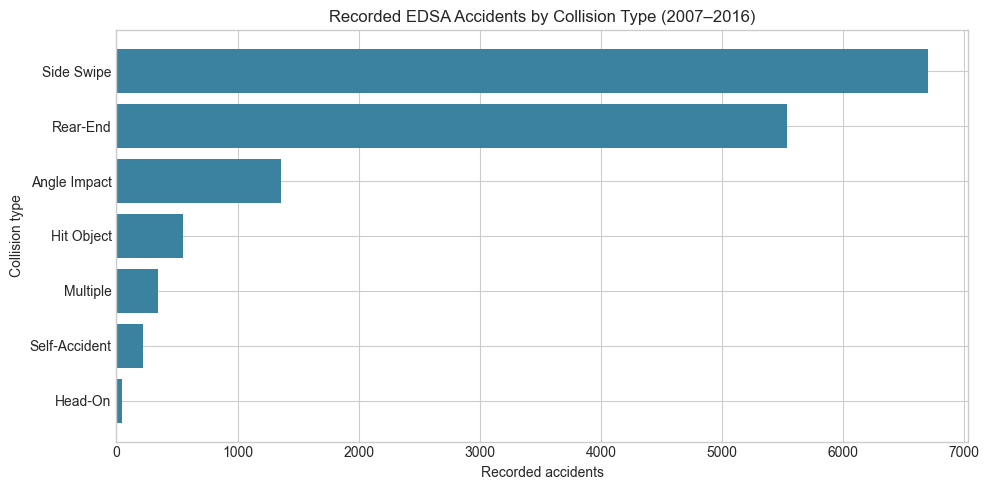

In [8]:
plot_collision_frequency(collision_frequencies)
plt.show()

Side Swipe is the most common type with 6,700 records (45.43%), followed by Rear-End with 5,535 (37.53%). Head-On has only 45 records (0.31%). The median category count is 550, while the standard deviation is 2,791.58 and the range is 6,655. This strong imbalance means a dominant class could obscure smaller but distinct collision profiles.

## EDA Question 2

**Where are recorded accident locations most densely concentrated along EDSA?**

The raw longitude and latitude values are summarized using their means, medians, standard deviations, ranges, and IQRs. Pearson correlation describes the overall direction of the corridor. A fixed 30-by-30 coordinate grid identifies the most populated cell without creating named sectors. This establishes whether location contains hotspot structure worth including in Phase 2 clustering.

In [9]:
coordinate_summary = overall_coordinate_statistics(clean_df)
coordinate_corr = overall_coordinate_correlation(clean_df)
density_peak = densest_coordinate_cell(clean_df, bins=30)
print(coordinate_summary.round(5))
print(f"\nOverall Pearson X-Y correlation: {coordinate_corr:.3f}")
print("\nMost populated 30-by-30 coordinate-grid cell:")
print(density_peak.round(5))

     count       mean     median      std        min        max    range  \
X  14749.0  121.03124  121.03758  0.02182  120.98369  121.05988  0.07620   
Y  14749.0   14.59713   14.59327  0.04350   14.53539   14.65788  0.12249   

       iqr  
X  0.03105  
Y  0.07877  

Overall Pearson X-Y correlation: -0.182

Most populated 30-by-30 coordinate-grid cell:
count       766.00000
x_center    121.02814
y_center     14.54968
x_min       121.02687
x_max       121.02941
y_min        14.54764
y_max        14.55172
dtype: float64


A hexagonal density plot shows where recorded accidents accumulate while preserving the raw coordinate space. A logarithmic color scale keeps both dense and less-dense portions of the corridor visible.

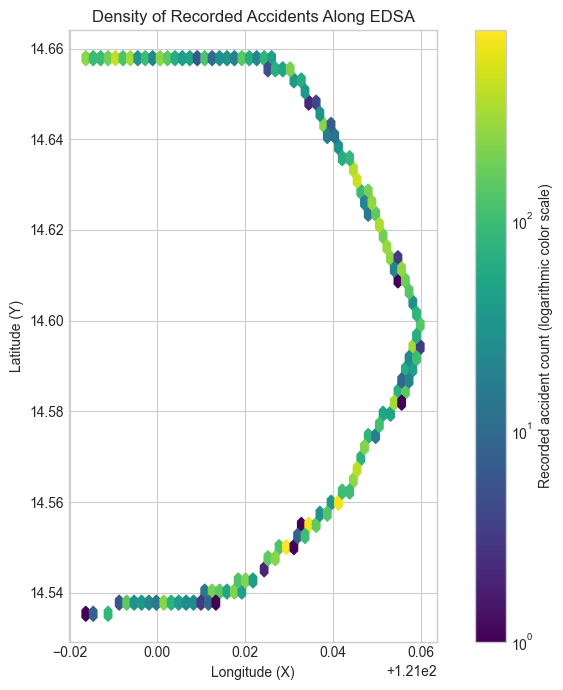

In [10]:
plot_coordinate_density(clean_df)
plt.show()

Recorded accidents are unevenly distributed along the corridor rather than forming a uniform line. The most populated 30-by-30 cell contains 766 records and is centered near longitude 121.02814 and latitude 14.54968. The overall X-Y correlation is weakly negative (-0.182), reflecting EDSA's curved path. These hotspots justify retaining both raw coordinates for clustering, without claiming that density alone explains collision type.

## EDA Question 3

**How does the time of day vary across collision types?**

Hour summaries provide central tendency and dispersion. Time-bin percentages compare categories of different sizes, while correlations between their 24-hour count profiles show which types rise and fall at similar times.

In [11]:
print("Hour statistics:")
print(hour_statistics(clean_df).round(2))
print("\nModal hour:")
print(modal_hour_by_collision(clean_df))
print("\nWithin-type time-bin percentages:")
print(time_distribution(clean_df).round(2))
print("\nHourly-pattern correlations:")
print(hourly_pattern_correlations(clean_df).round(2))

Hour statistics:
                 count   mean   std  min  25%   50%   75%   max
COLLISION_TYPE                                                 
Angle Impact    1355.0  12.98  5.77  0.0  9.0  13.0  18.0  23.0
Head-On           45.0  11.00  6.42  0.0  7.0  10.0  16.0  23.0
Hit Object       550.0  10.72  6.91  0.0  5.0  10.0  16.0  23.0
Multiple         345.0  12.54  5.67  0.0  8.0  12.0  17.0  23.0
Rear-End        5535.0  12.53  5.33  0.0  9.0  12.0  16.0  23.0
Self-Accident    219.0  10.63  7.33  0.0  4.0   9.0  18.0  23.0
Side Swipe      6700.0  13.47  5.53  0.0  9.0  14.0  18.0  23.0

Modal hour:
COLLISION_TYPE
Angle Impact     12
Head-On          10
Hit Object        1
Multiple          8
Rear-End         10
Self-Accident     1
Side Swipe       19
Name: HOUR, dtype: int32

Within-type time-bin percentages:
TIME_BIN        Night (0-6)  Morning (6-12)  Afternoon (12-18)  \
COLLISION_TYPE                                                   
Angle Impact          10.33           29.52    

The heatmap normalizes every collision type separately. It therefore compares temporal shape rather than allowing the two largest classes to dominate the color scale.

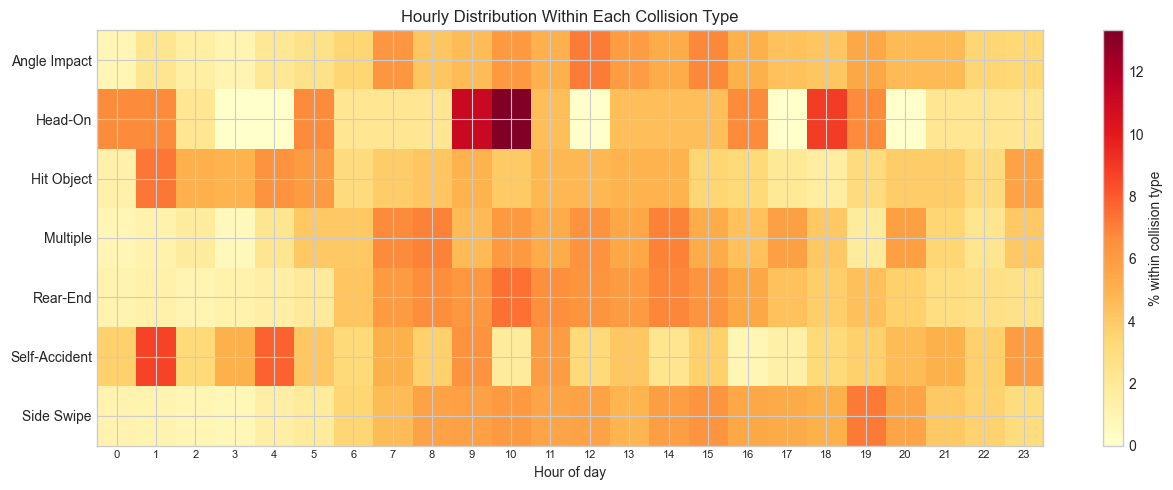

In [12]:
plot_hourly_collision_heatmap(clean_df)
plt.show()

Hit Object and Self-Accident are comparatively nighttime-oriented: 30.91% and 32.42% of their records occur from 00:00 to 05:59. Rear-End and Side Swipe have only 7.84% and 7.10% in that period. Their hourly patterns are negatively correlated with Self-Accident but strongly correlated with each other. Time therefore adds information not visible in the spatial comparison.

## EDA Question 4

**How does recorded severity vary across collision types?**

Within-type percentages prevent large collision classes from dominating the comparison. Correlations between severity counts show whether collision types with many property-damage records also tend to have many injury or fatal records.

In [13]:
severity_percentages = severity_distribution(clean_df)
print("Severity percentage within each collision type:")
print(severity_percentages.round(2))
print("\nCorrelations between severity count patterns:")
print(severity_count_correlations(clean_df).round(3))

Severity percentage within each collision type:
SEVERITY        Property  Injury  Fatal
COLLISION_TYPE                         
Angle Impact       91.14    8.78   0.07
Head-On            77.78   22.22   0.00
Hit Object         90.00   10.00   0.00
Multiple           80.29   19.71   0.00
Rear-End           95.92    3.96   0.13
Self-Accident      59.82   38.81   1.37
Side Swipe         94.91    5.01   0.07

Correlations between severity count patterns:
SEVERITY  Property  Injury  Fatal
SEVERITY                         
Property     1.000   0.959  0.861
Injury       0.959   1.000  0.814
Fatal        0.861   0.814  1.000


Three horizontal panels display Property, Injury, and Fatal percentages separately. Each panel has its own horizontal scale, preventing the dominant Property category from hiding the smaller Injury and Fatal differences.

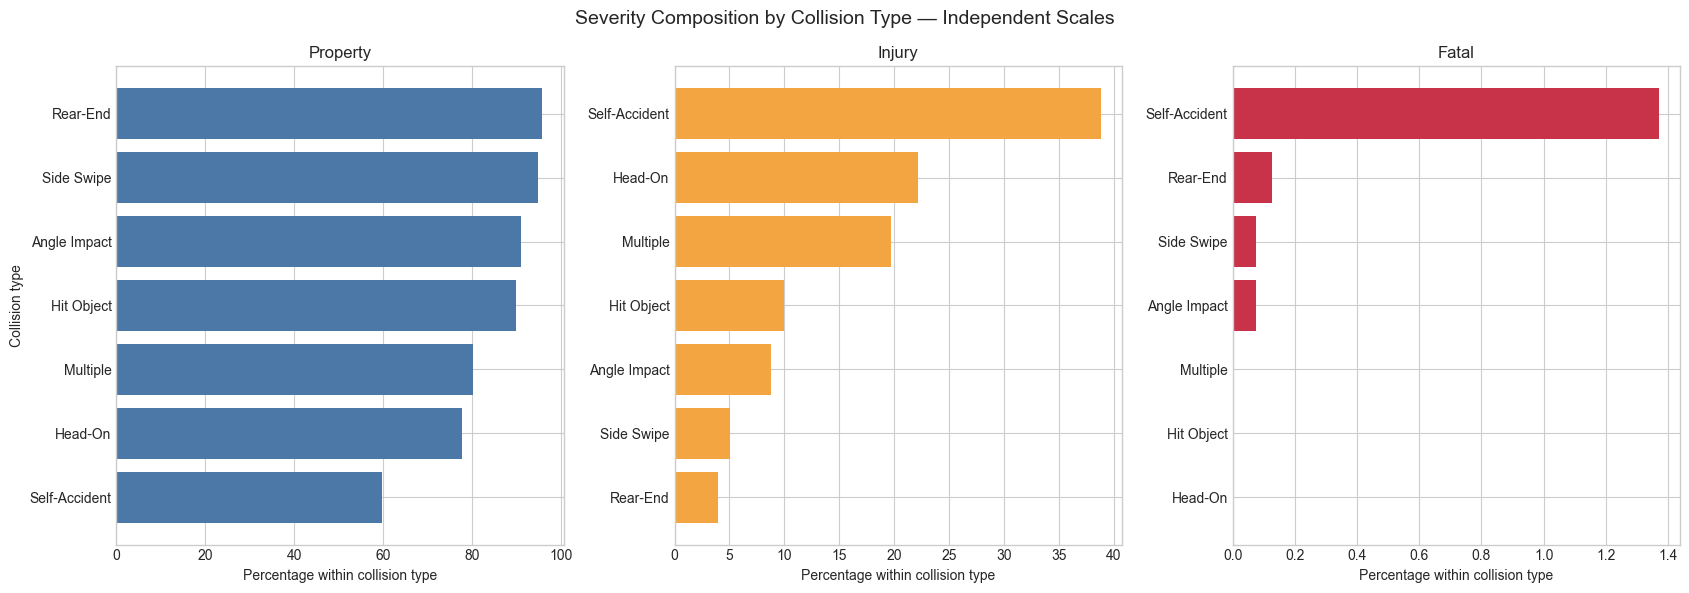

In [14]:
plot_severity_distribution(severity_percentages)
plt.show()

The independent panels make the imbalance and the smaller categories visible at the same time. Property damage dominates every type, but Self-Accident has 38.81% Injury and 1.37% Fatal. Head-On and Multiple have injury shares of 22.22% and 19.71%. Severity can therefore help distinguish accident profiles even though it is not the research outcome.

# Section 4: Research Question

**What spatial, temporal, and severity-based accident profiles exist along EDSA, and which collision types characterize these profiles from 2007 to 2016?**

The question follows from the EDA. Collision types are highly imbalanced, overlap geographically, and show different hourly and severity compositions. A single variable is therefore insufficient to describe them. 

Clustering can combine raw location, time, and severity to identify accident profiles without using collision type to construct the clusters. Collision type can then characterize the composition of each resulting cluster.

This question is significant because it can distinguish common recorded accident patterns from less frequent spatial-temporal patterns with different collision and severity compositions. The results may help organize historical road-safety observations by when, where, and how recorded accidents occurred. They should not be interpreted as causal or current predictions.

# Phase 2

Phase 2 will answer the research question using K-means clustering, hypothesis testing, and cluster interpretation. Each accident remains one observation. 

`COLLISION_TYPE` will not be used to create clusters; it will be used afterward to describe and statistically evaluate them.

## 1. Data Modelling

### 1.1 Modelling Preprocessing

Create a separate modelling matrix from `clean_df`. Standardize `X` and `Y`, convert exact hour to sine and cosine, and one-hot encode severity. The binary severity columns are not standardized, which avoids magnifying the rare Fatal category. Retain the original columns for interpretation. `TIME_BIN` is not a clustering input. A second matrix adds standardized `YEAR` so its usefulness can be evaluated rather than assumed.

In [15]:
from models.clustering import (
    circular_mean_hour,
    cluster_centroids,
    cluster_composition,
    evaluate_candidate_clusters,
    fit_final_clusters,
    prepare_modelling_features,
    summarize_clusters,
)
from models.cluster_plots import (
    plot_cluster_collision_heatmap,
    plot_cluster_hourly_distribution,
    plot_cluster_selection,
    plot_cluster_severity_composition,
    plot_clusters_in_coordinate_space,
)

X_model, preprocessing = prepare_modelling_features(clean_df)
X_model_with_year, preprocessing_with_year = prepare_modelling_features(
    clean_df, include_year=True
)

print("Base feature matrix:", X_model.shape)
print("Features:", X_model.columns.tolist())
print("Missing values:", int(X_model.isna().sum().sum()))
print("\nFeature summary:")
print(X_model.agg(["mean", "std", "min", "max"]).T.round(3))
print("\nOptional matrix with YEAR:", X_model_with_year.shape)

Base feature matrix: (14749, 7)
Features: ['X_SCALED', 'Y_SCALED', 'HOUR_SIN', 'HOUR_COS', 'SEVERITY_PROPERTY', 'SEVERITY_INJURY', 'SEVERITY_FATAL']
Missing values: 0

Feature summary:
                    mean    std    min    max
X_SCALED           0.000  1.000 -2.180  1.313
Y_SCALED          -0.000  1.000 -1.419  1.396
HOUR_SIN          -0.084  0.712 -1.000  1.000
HOUR_COS          -0.262  0.646 -1.000  1.000
SEVERITY_PROPERTY  0.938  0.240  0.000  1.000
SEVERITY_INJURY    0.060  0.238  0.000  1.000
SEVERITY_FATAL     0.001  0.033  0.000  1.000

Optional matrix with YEAR: (14749, 8)


### 1.2 Selecting the Number of Clusters

Evaluate using Within-Cluster Sum of Squares (WCSS) for `k=1` through `k=10` so every reduction from `k=2` onward has a previous value. Silhouette scores are calculated from `k=2` through `k=10`, because one cluster cannot have between-cluster separation. 

Present both measures in one two-panel figure. 

Finally, select a value that balances a visible elbow, a comparatively strong silhouette score, adequate cluster sizes, and understandable composition.

Base features:
 K       WCSS  WCSS_REDUCTION_PERCENT  SILHOUETTE  MIN_CLUSTER_SIZE  MAX_CLUSTER_SIZE
 1 44835.8358                     NaN         NaN             14749             14749
 2 30336.7485                 32.3382      0.3694              3198             11551
 3 21589.8102                 28.8328      0.3279              3054              5907
 4 18509.9520                 14.2653      0.2996              2882              4524
 5 16031.2074                 13.3914      0.3100              2697              3297
 6 14332.3213                 10.5974      0.3148              1518              2799
 7 13031.3646                  9.0771      0.3190              1357              2597
 8 11889.3728                  8.7634      0.3014              1367              2437
 9 10920.7305                  8.1471      0.2998              1260              2022
10 10145.1356                  7.1020      0.3059              1016              2010

Features including YEAR:
 K       WCSS

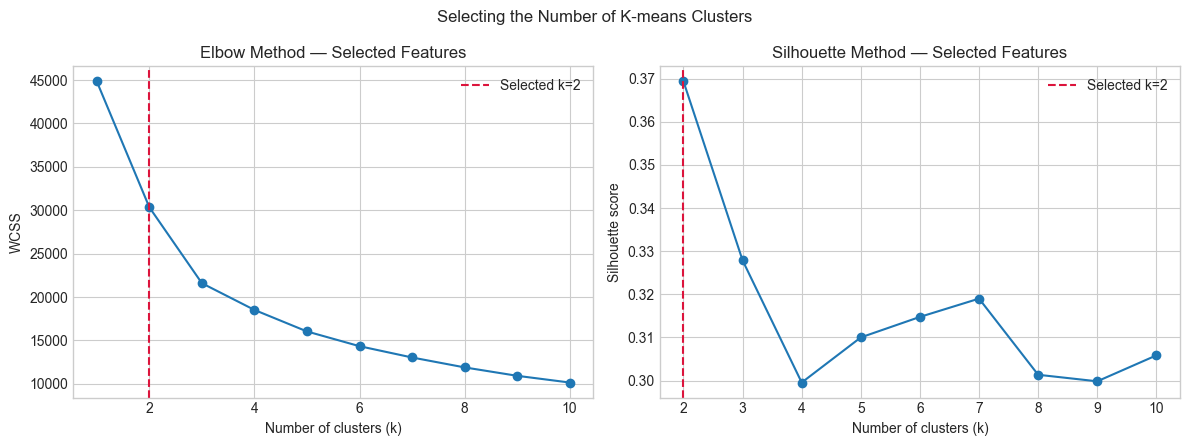

Selected feature set: Coordinates + cyclic hour + severity
Selected number of clusters: k=2


In [16]:
base_selection = evaluate_candidate_clusters(X_model)
year_selection = evaluate_candidate_clusters(X_model_with_year)

print("Base features:")
print(base_selection.round(4).to_string(index=False))
print("\nFeatures including YEAR:")
print(year_selection.round(4).to_string(index=False))

selected_features = X_model
selected_feature_name = "Coordinates + cyclic hour + severity"
selected_k = 2

plot_cluster_selection(base_selection, selected_k)
plt.show()

print(f"Selected feature set: {selected_feature_name}")
print(f"Selected number of clusters: k={selected_k}")

Adding `YEAR` reduced the silhouette score for every valid candidate, so the date is excluded. 

The base WCSS decreases by 32.34% at `k=2`, another 28.83% at `k=3`, and only 14.27% at `k=4`, placing the elbow around three clusters. However, `k=2` has the highest silhouette score (0.369), which is stronger direct evidence of separation than the score for `k=3` (0.328). 

To avoid forcing an additional group, the simpler `k=2` solution is selected and its broad, unequal cluster sizes are treated as a finding rather than automatically as a defect.

### 1.3 Final Clustering and Characterization

Fit the final K-means model and attach its `CLUSTER` label to the original cleaned records. For every cluster, report its size, coordinate center and spread, hourly pattern, severity percentages, and collision-type percentages. 

Use the original coordinates and hour—not transformed values—when explaining what a cluster represents.

Cluster summary using original values:
         ACCIDENTS  PERCENT    X_MEAN   Y_MEAN   X_STD   Y_STD  MODAL_HOUR  CIRCULAR_MEAN_HOUR
CLUSTER                                                                                       
1            11551  78.3172  121.0390  14.5806  0.0161  0.0340          10             13.0949
2             3198  21.6828  121.0031  14.6569  0.0158  0.0012          15             13.5823

Severity composition (%):
SEVERITY  Property  Injury  Fatal
CLUSTER                          
1            94.49    5.40   0.11
2            91.53    8.38   0.09

Collision-type composition (%):
COLLISION_TYPE  Angle Impact  Head-On  Hit Object  Multiple  Rear-End  Self-Accident  Side Swipe
CLUSTER                                                                                         
1                       8.45     0.29        3.59      2.55     39.71           1.44       43.96
2                      11.85     0.34        4.22      1.56     29.64           1.66       50.

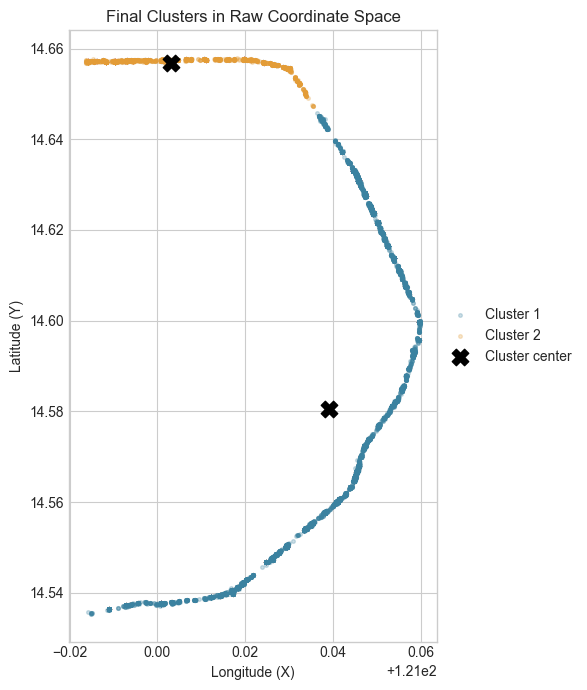

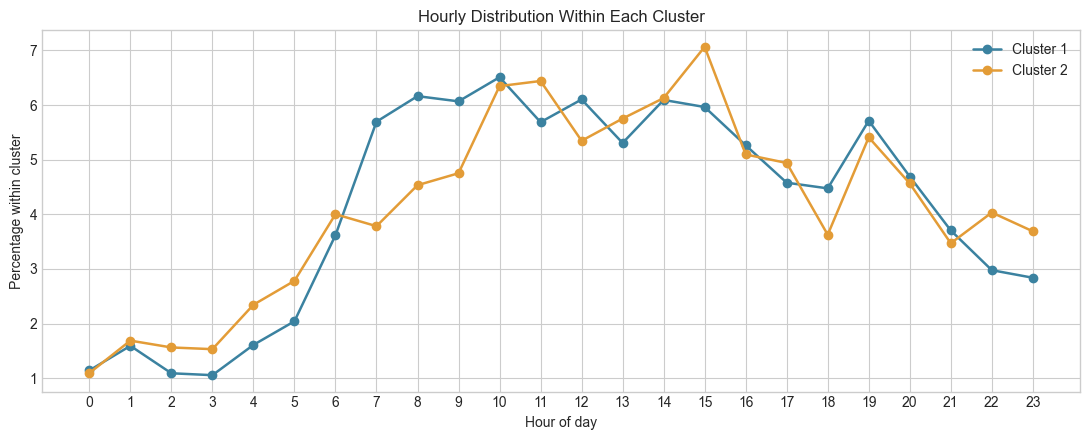

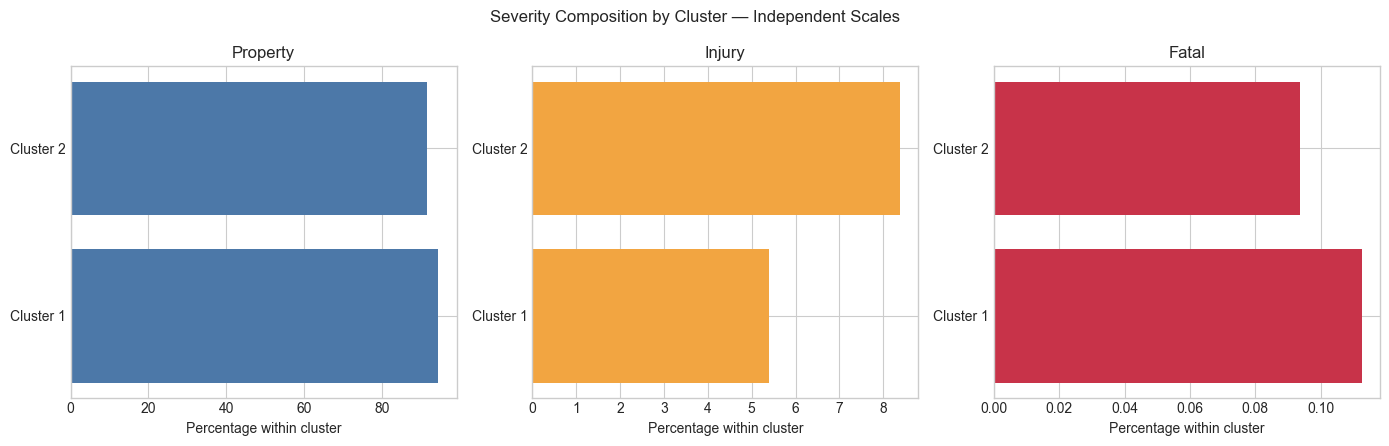

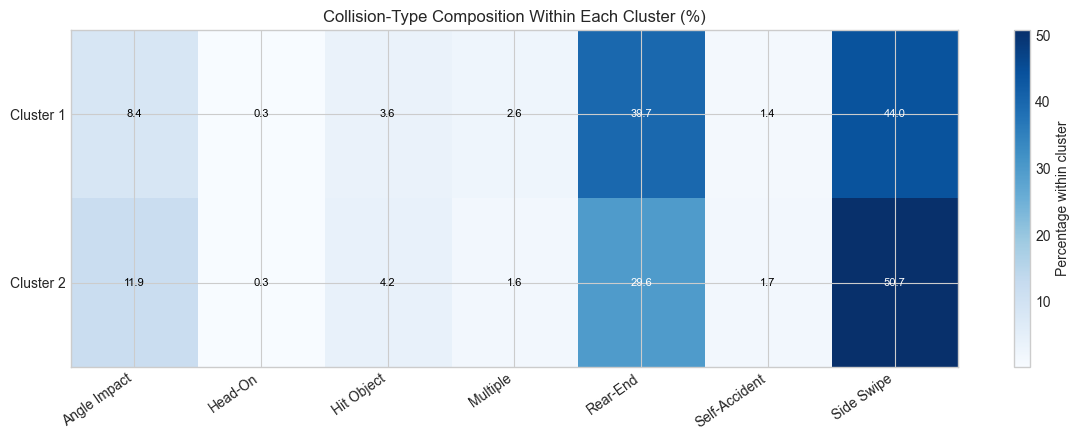

In [17]:
clustered_df, final_model = fit_final_clusters(
    clean_df, selected_features, n_clusters=selected_k
)

cluster_summary = summarize_clusters(clustered_df)
cluster_severity_pct = cluster_composition(clustered_df, "SEVERITY", VALID_SEVERITIES)
cluster_collision_pct = cluster_composition(clustered_df, "COLLISION_TYPE", COLLISION_TYPES)
cluster_hour_pct = cluster_composition(clustered_df, "HOUR", range(24))
cluster_centroids_scaled = cluster_centroids(final_model, selected_features.columns)

print("Cluster summary using original values:")
print(cluster_summary.round(4).to_string())
print("\nSeverity composition (%):")
print(cluster_severity_pct.round(2).to_string())
print("\nCollision-type composition (%):")
print(cluster_collision_pct.round(2).to_string())
print("\nCentroids in the seven-feature modelling space:")
print(cluster_centroids_scaled.round(3).to_string())

# Figure 6: raw coordinates colored by cluster
plot_clusters_in_coordinate_space(clustered_df, cluster_summary)
plt.show()

# Figure 7: exact-hour distribution by cluster
plot_cluster_hourly_distribution(cluster_hour_pct)
plt.show()

# Figure 8: severity composition with independent scales
plot_cluster_severity_composition(cluster_severity_pct)
plt.show()

# Figure 9: collision-type composition heatmap
plot_cluster_collision_heatmap(cluster_collision_pct)
plt.show()

The two-cluster solution is mainly geographic. 

- Cluster 1 contains 11,551 accidents (78.32%) across the broad lower- and middle-latitude portion of the data, while Cluster 2 isolates 3,198 accidents (21.68%) in a narrow high-latitude band.  

- Cluster 1 has a higher Rear-End share (39.71% versus 29.64%). Cluster 2 has more Injury records (8.38% versus 5.40%) and higher Side Swipe (50.72% versus 43.96%) and Angle Impact shares (11.85% versus 8.45%).

- Their circular mean hours are both near 13:00, so time does not distinguish them strongly.

- Fatal remains approximately 0.1% in both. 

Therefore, `k=2` provides a simpler, better-separated spatial division with secondary severity and collision differences, but one cluster remains intentionally broad. Cluster numbers are arbitrary identifiers rather than rankings.

## 2. Statistical Inference

A chi-square test evaluates whether the collision-type distribution differs between clusters. Collision type was excluded from clustering, so it serves as an external categorical variable.

- **Null hypothesis:** Cluster membership and collision type are independent.
- **Alternative hypothesis:** Cluster membership and collision type are associated.
- **Planned significance level:** `α = 0.05`

The test requires independent observations and adequate expected counts. The code checks expected counts and uses standardized residuals to identify important differences.

In [18]:
from models.inference import cluster_collision_chi_square

inference = cluster_collision_chi_square(clustered_df)
expected = inference["expected"]
assumptions_met = bool((expected >= 5).all().all())

print("Observed contingency table:")
display(inference["contingency"])
print("Expected counts under the null hypothesis:")
display(expected.round(2))
print(f"Minimum expected count: {expected.to_numpy().min():.2f}")
print(f"Cells with expected count below 5: {(expected < 5).to_numpy().sum()}")
print(f"Expected-count requirement met: {assumptions_met}")
print(f"Chi-square statistic: {inference['chi2']:.4f}")
print(f"Degrees of freedom: {inference['degrees_of_freedom']}")
print(f"p-value: {inference['p_value']:.6e}")
print("Standardized residuals (absolute values above 2 are notable):")
display(inference["standardized_residuals"].round(2))

Observed contingency table:


COLLISION_TYPE,Angle Impact,Head-On,Hit Object,Multiple,Rear-End,Self-Accident,Side Swipe
CLUSTER,,,,,,,
1,976,34,415,295,4587,166,5078
2,379,11,135,50,948,53,1622


Expected counts under the null hypothesis:


COLLISION_TYPE,Angle Impact,Head-On,Hit Object,Multiple,Rear-End,Self-Accident,Side Swipe
CLUSTER,,,,,,,
1,1061.2,35.24,430.74,270.19,4334.86,171.51,5247.25
2,293.8,9.76,119.26,74.81,1200.14,47.49,1452.75


Minimum expected count: 9.76
Cells with expected count below 5: 0
Expected-count requirement met: True
Chi-square statistic: 138.5411
Degrees of freedom: 6
p-value: 2.036014e-27
Standardized residuals (absolute values above 2 are notable):


COLLISION_TYPE,Angle Impact,Head-On,Hit Object,Multiple,Rear-End,Self-Accident,Side Swipe
CLUSTER,,,,,,,
1,-2.62,-0.21,-0.76,1.51,3.83,-0.42,-2.34
2,4.97,0.40,1.44,-2.87,-7.28,0.80,4.44


### Statistical Decision

Each accident report contributes to exactly one contingency-table cell, and collision type was excluded when the clusters were created. The minimum expected count is 9.76, above the required five, so no categories are combined. 

The test gives `chi-square(6) = 138.5411`, `p = 2.036 × 10^-27`. Because `p < 0.05`, reject the null hypothesis: cluster and collision type are associated.

The largest residuals show that Cluster 2 has more Angle Impact and Side Swipe and fewer Rear-End records than expected under independence.

## 3. Insights and Conclusions

**To answer the research question:**

**What spatial, temporal, and severity-based accident profiles exist along EDSA, and which collision types characterize these profiles from 2007 to 2016?**


The two clusters represent a broad lower/middle-EDSA profile and a narrower high-latitude profile. Their time patterns are similar, with circular mean hours near 13:00, so location is the strongest distinction. The high-latitude cluster has relatively more Injury, Side Swipe, and Angle Impact records, whereas the broader cluster has relatively more Property and Rear-End records.

The collision-type differences are statistically supported by the chi-square test (`p = 2.036 × 10^-27`). Thus, the main finding is geographic separation with smaller collision-type and severity differences—not two completely different kinds of accidents.

The result describes recorded accidents rather than causes or road risk because the data has no traffic-volume denominator. It applies only to official EDSA records from 2007–2016.

## Reference

Luz, L., & Blanco, A. (2019). *Road Traffic Accident Data of Epifanio delos Santos Avenue, Metro Manila (2007–2016)* (Version 1) [Data set]. Mendeley Data. https://doi.org/10.17632/hwbf6n4krw.1